# Inter-scanner variability of FC matrices

In [1]:
library(reticulate)
library(tidyr)
library(MANOVA.RM)
library(irr)
library(effectsize)
use_python("/home/cprovins/miniconda3/envs/pymc_env/bin/python", required = TRUE)

Loading required package: lpSolve



## Load the FC matrices

We load the functional connectivity (FC) matrices using Python code so we can conveniently leverage our custom configuration for PyBIDS. Which scanner was the participant scanned on is encoded in the last three digits of the session number (Prisma=060, Vida=034, VidaFit=030).

In [2]:
py_run_string('
import re
import pandas as pd
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths

# Define filtering parameters
metric = "sparseinversecovariance"
atlas_dimension = "64"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/hcph-fc")

# Initialize the BIDS layout
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration \'hcph\' already exists" in str(e):
        print("Configuration hcph already exists, skipping add_config_paths.")
    else:
        raise e

_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)       
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)

# Load files
entities_base = {
    "subject": "001",
    "task": "rest",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}
# Get functional connectivity files
files = layout.get(**entities_base, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files) == 36, f"Expected 36 FC matrices, got {len(files)}"
df_fc = pd.DataFrame({"filename": files, "subject": "001"})

# Retrieve which scanner was used for each session (encoded in the last three digits of the session ID)
df_fc["session"] = df_fc["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)

def extract_scanner(session):
    scanner_codes = {"060": "prisma", "034": "vida", "030": "vidafit"}
    code = session[-3:]
    return scanner_codes.get(code, "unknown")

df_fc["scanner"] = df_fc["session"].apply(extract_scanner)
df_fc["repetition"] = df_fc["session"].str[1:3].astype(int)
df_fc["order"] = df_fc["session"].str[4:5].astype(int)
')

In [3]:
# Load the panda DataFrame into R
df_fc <- as.data.frame(py$df_fc)
head(df_fc)

,filename,subject,session,scanner,repetition,order
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,/data/derivatives/hcph-fc/sub-001/ses-20101060/func/sub-001_ses-20101060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20101060,prisma,1,1
2,/data/derivatives/hcph-fc/sub-001/ses-20102030/func/sub-001_ses-20102030_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20102030,vidafit,1,2
3,/data/derivatives/hcph-fc/sub-001/ses-20103034/func/sub-001_ses-20103034_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20103034,vida,1,3
4,/data/derivatives/hcph-fc/sub-001/ses-20201060/func/sub-001_ses-20201060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20201060,prisma,2,1
5,/data/derivatives/hcph-fc/sub-001/ses-20202030/func/sub-001_ses-20202030_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20202030,vidafit,2,2
6,/data/derivatives/hcph-fc/sub-001/ses-20203034/func/sub-001_ses-20203034_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20203034,vida,2,3


## Intra-class correlation coefficient (ICC) to quantify between-scanner variability

In [7]:
icc_results <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_fc[, c( "scanner", edge)]
    df_icc <- pivot_wider(df_icc, names_from = scanner, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(prisma, vida, vidafit))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_results <- rbind(icc_results, data.frame(edge = edge, ICC = icc_val))
}
head(df_icc)
head(icc_results)

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(edge)

  # Now:
  data %>% select(all_of(edge))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


prisma,vidafit,vida
<dbl>,<dbl>,<dbl>
5.167582e-17,-1.750475e-18,-1.469841e-16
-3.850324e-17,4.744856e-17,-2.062372e-17
1.681766e-17,5.344078e-18,1.076156e-16
-1.098919e-16,1.718209e-17,1.452872e-17
1.035807e-02,-5.010170e-17,6.270949e-17
-7.349301e-17,-1.836159e-16,-8.626545e-17


,edge,ICC
,<chr>,<dbl>
1,edge1,-0.0172390994
2,edge2,-0.0469087433
3,edge3,-0.0234311629
4,edge4,-0.1738795027
5,edge5,-0.0539968901
6,edge6,-0.0003582582


Mean ICC across edges: -0.02419042 
Median ICC across edges: -0.01757463 


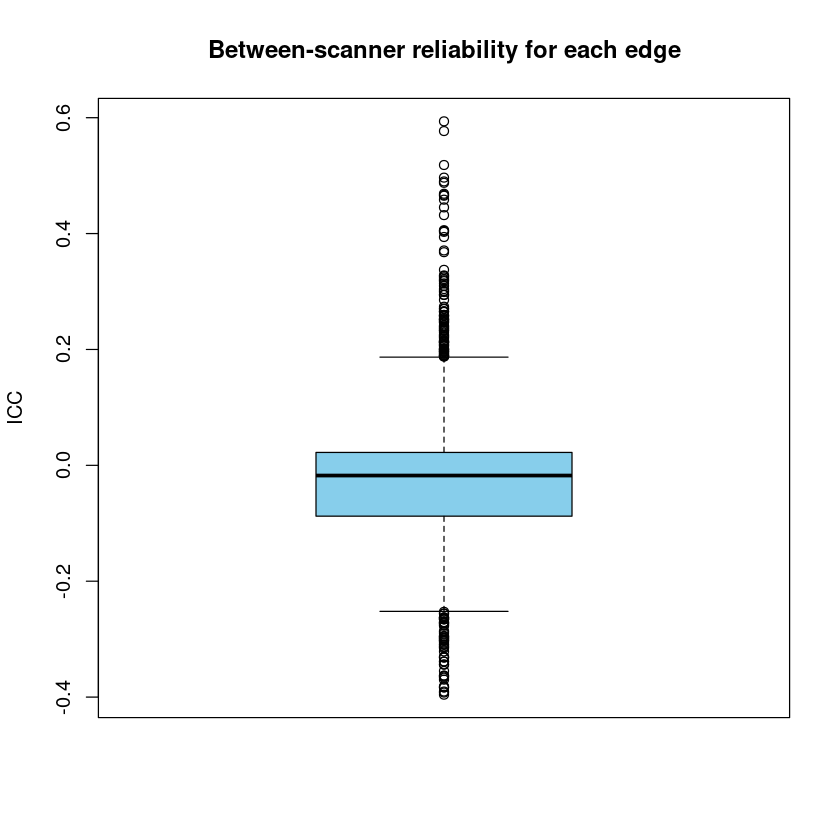

In [8]:
mean_icc <- mean(icc_results$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_results$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_results$ICC, main = "Between-scanner reliability for each edge", ylab = "ICC", col = "skyblue")

In [9]:
icc_results <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), stringsAsFactors = FALSE)

for (rep in unique(df_fc$repetition)) {
    df_rep <- df_fc[df_fc$repetition == rep, ]
    # Keep only the edge and session columns
    colnames <- df_rep$scanner
    df_rep <- t(df_rep[, edge_keys])
    colnames(df_rep) <- colnames
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
    icc_results <- rbind(icc_results, data.frame(variability_type = "between-scanner", task="rest", scanner=NA, repetition = rep, ICC = icc_val, summary_statistic = NA))
}
head(df_rep)
icc_results

,vidafit,vida,prisma
edge1,-1.052766e-06,-1.245544e-05,-1.738165e-06
edge2,-1.828220e-06,8.131475e-06,-1.091652e-06
edge3,1.497237e-01,-2.167989e-05,1.356319e-05
edge4,1.552997e-01,1.151996e-05,6.414071e-02
edge5,-3.903089e-07,-7.215465e-06,4.221924e-07
edge6,-1.300343e-06,5.341054e-06,3.592163e-07


variability_type,task,scanner,repetition,ICC,summary_statistic
<chr>,<chr>,<lgl>,<chr>,<dbl>,<lgl>
between-scanner,rest,NA,1,0.7922871,NA
between-scanner,rest,NA,2,0.7646605,NA
between-scanner,rest,NA,3,0.7716107,NA
between-scanner,rest,NA,4,0.7551428,NA
between-scanner,rest,NA,5,0.7457270,NA
between-scanner,rest,NA,6,0.7672918,NA
between-scanner,rest,NA,7,0.7828802,NA
between-scanner,rest,NA,8,0.7736591,NA
between-scanner,rest,NA,9,0.8384995,NA


Mean ICC across edges: 0.781667 
Quantiles (25%, median, 75%): 0.766634 0.7782696 0.7919817 


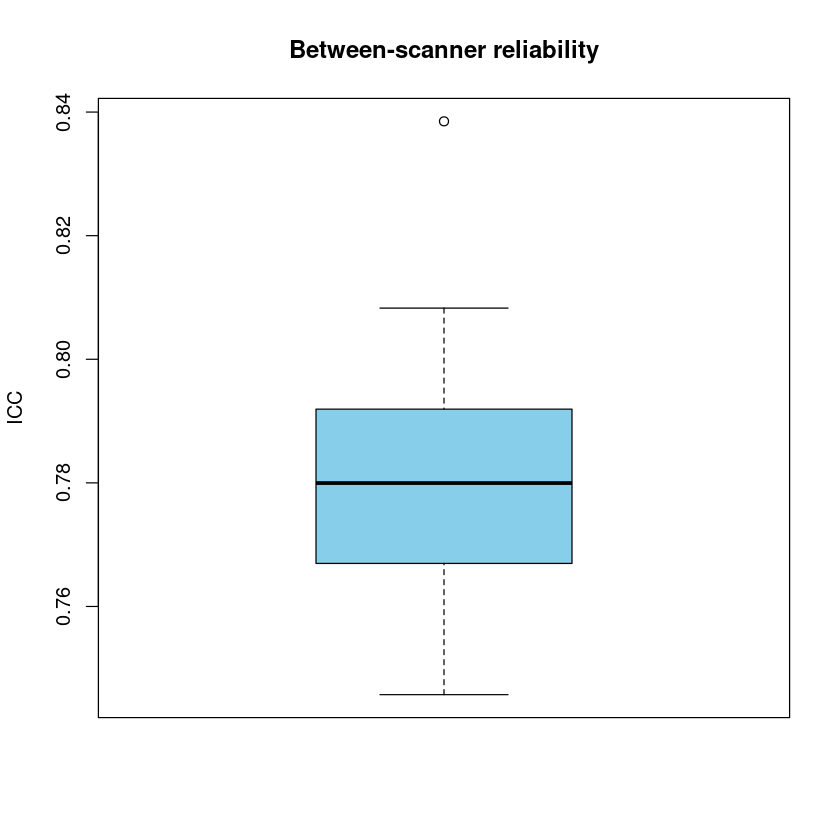

In [10]:
mean_icc <- mean(icc_results$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_results$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_results <- rbind(
    icc_results,
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = mean_icc, summary_statistic = "mean"),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[2], summary_statistic = "median"),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25"),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75")
)

boxplot(icc_results$ICC, main = "Between-scanner reliability", ylab = "ICC", col = "skyblue")

In [11]:
icc_results

,variability_type,task,scanner,repetition,ICC,summary_statistic
,<chr>,<chr>,<lgl>,<chr>,<dbl>,<chr>
1,between-scanner,rest,NA,1,0.7922871,NA
2,between-scanner,rest,NA,2,0.7646605,NA
3,between-scanner,rest,NA,3,0.7716107,NA
4,between-scanner,rest,NA,4,0.7551428,NA
5,between-scanner,rest,NA,5,0.7457270,NA
6,between-scanner,rest,NA,6,0.7672918,NA
7,between-scanner,rest,NA,7,0.7828802,NA
8,between-scanner,rest,NA,8,0.7736591,NA
9,between-scanner,rest,NA,9,0.8384995,NA


## ICC to quantify intra-scanner variability

Let's quantify the intra-scanner reliability of FC estimates when using the standard fixation cross task for resting-state.

In [12]:
for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    df_scanner <- t(df_scanner[, edge_keys])
    icc_val <- icc(df_scanner, model = "twoway", type = "agreement", unit = "single")$value
    cat(sprintf("ICC of for %s scanner: %.4f\n", scanner, icc_val))
    icc_results <- rbind(
        icc_results,
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = icc_val, summary_statistic = NA)
    )
}
head(df_scanner)

ICC of for prisma scanner: 0.7800
ICC of for vidafit scanner: 0.7962
ICC of for vida scanner: 0.8155


,3,6,8,11,14,16,19,23,27,30,31,35
edge1,6.528042e-06,-4.514564e-06,-8.506657e-06,-3.215814e-06,-5.611867e-06,-1.163362e-06,-1.055886e-06,9.467434e-07,3.087218e-06,1.113368e-06,-4.712413e-06,-1.245544e-05
edge2,7.514955e-06,2.766009e-02,-4.268188e-06,-1.695434e-06,-9.683560e-07,3.029625e-06,-9.775773e-06,-1.016135e-06,7.646137e-07,-4.235880e-06,-6.342809e-06,8.131475e-06
edge3,6.689939e-02,1.460895e-05,9.157005e-02,9.144441e-02,3.725246e-03,1.416232e-01,9.480423e-08,4.164482e-02,1.045742e-02,-4.391880e-06,8.693893e-02,-2.167989e-05
edge4,7.235371e-06,4.672855e-04,1.805981e-02,6.709116e-02,6.825498e-02,5.305358e-02,4.791103e-02,1.185077e-02,-2.287152e-05,2.343900e-05,9.511922e-03,1.151996e-05
edge5,-7.886987e-07,-4.646385e-06,-4.847092e-06,-7.981107e-07,1.155399e-07,-1.123034e-06,7.750204e-07,-9.281694e-09,1.307680e-06,-1.880596e-06,6.730842e-08,-7.215465e-06
edge6,7.797121e-06,-2.661734e-07,-1.059137e-06,-1.370371e-06,-2.018452e-06,1.328749e-07,-2.814641e-07,-2.565683e-07,-3.477949e-07,-1.781178e-06,-2.678140e-09,5.341054e-06


Use pybids to save the ICC values for reporting in supplementary material

In [17]:
py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'iccinter'
}
entities.update(entities_base)
entities.pop('task', None)
save_path = save_layout.build_path(entities, validate=False)
#")

write.table(icc_results, file = py$save_path, sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)
